# AutoTrader Car Listings — Exploratory Analysis

Exploring the `data/` sample (30 days of daily snapshots, up to 1,000 rows/day, `data/data/*.parquet`).

**Note on premium fields:** `salePrice`, `kbbFairPurchasePrice`, `sellerRating`, `sellerName`, `sellerPhone`, `sellerWebsite`, `vin`, `images`, and `listingUrl` are masked as `"[PREMIUM]"` in this sample, so pricing analysis below leans on `kbbFairPriceLow`/`kbbFairPriceHigh` (KBB fair-price range) and `msrp` instead of `salePrice`.

Sections:
1. Load & clean data
2. Data quality overview
3. Inventory composition (listing type, body style, make)
4. Geographic distribution
5. KBB pricing analysis
6. Days-on-market & listing dynamics
7. Fuel type / EV trends
8. Deal quality ratings

In [1]:
import glob
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_DIR = Path("data/data")
files = sorted(DATA_DIR.glob("*.parquet"))
print(f"{len(files)} parquet files, {files[0].name} → {files[-1].name}")

Matplotlib is building the font cache; this may take a moment.


30 parquet files, 2026-07-01.parquet → 2026-07-30.parquet


In [2]:
# Load every daily snapshot and concatenate. A listing can appear in several
# daily files as it stays on market, so keep the raw (all-snapshots) frame for
# time-based analysis and a deduped "latest" frame (one row per listing) for
# cross-sectional analysis.
raw = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)
raw["_firstSeenAt"] = pd.to_datetime(raw["_firstSeenAt"], utc=True)
raw["_lastSeenAt"] = pd.to_datetime(raw["_lastSeenAt"], utc=True)

# Coerce masked/premium numeric columns -> NaN where masked, numeric elsewhere.
for col in ["salePrice", "kbbFairPurchasePrice", "sellerRating"]:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

df = (
    raw.sort_values("_lastSeenAt")
    .drop_duplicates(subset="_primaryKey", keep="last")
    .reset_index(drop=True)
)

print(f"raw snapshots: {len(raw):,} rows")
print(f"unique listings (latest snapshot each): {len(df):,} rows, {df.shape[1]} columns")
df.head(3)

raw snapshots: 23,845 rows
unique listings (latest snapshot each): 23,845 rows, 71 columns


,_primaryKey,_firstSeenAt,_lastSeenAt,listingId,vin,stockNumber,year,makeCode,makeName,modelCode,modelName,trim,bodyStyle,listingType,listingTitle,mileage,salePrice,msrp,dealIndicator,kbbFairPurchasePrice,kbbFairPriceLow,kbbFairPriceHigh,exteriorColor,exteriorColorSimple,interiorColor,interiorColorSimple,engineCode,engine,drivetrain,transmissionCode,transmission,transmissionGroup,fuelTypeCode,fuelType,fuelTypeGroup,mpgCity,mpgHighway,displacementUOM,hasLeatherSeats,daysOnMarket,isHot,isNewlyListed,isReducedPrice,isNoHagglePrice,hasSpecialOffer,moneyBackGuarantee,mainImageIsStock,priority,sellerId,sellerName,sellerPhone,sellerRating,sellerReviewCount,sellerWebsite,isPrivateSeller,sellerContractLevel,kbbVehicleId,kbbConsumerRatings,kbbConsumerReviewCount,safetyRecallCount,vhrPreview,options,optionsCount,description,images,imagesCount,sellerAddress,sellerCity,sellerState,sellerZip,listingUrl
0,783885490,2026-07-01 15:04:47.528000+00:00,2026-07-01 15:04:47.528000+00:00,783885490,[PREMIUM],TME012157,2021,HONDA,Honda,CRV,CR-V,Touring,SUV,Used,Used 2021 Honda CR-V Touring,58128,NaN,NaN,Great,NaN,26400.0,30000.0,Aegean Blue Metallic,BLUE,Black,BLACK,4CLDR,4-Cylinder Turbo,2 wheel drive - front,AUT,Continuously Variable Automatic,Automatic,G,Gasoline,Gas,28.0,34.0,1.5,True,7.0,False,False,False,None,False,None,None,30,74636317.0,[PREMIUM],[PREMIUM],NaN,1449.0,[PREMIUM],False,PARTNER,450024.0,4.0,329.0,0.0,"[""NO_SALVAGE_TITLE"",""NO_ACCIDENTS_REPORTED"",""O...","{""exterior"":[""Alloy wheels"",""Auto High-beam He...",80.0,Recent Arrival! Come visit Spartanburg Imports...,[PREMIUM],37.0,400 East Daniel Morgan Avenue,Spartanburg,SC,29302,[PREMIUM]
1,784093471,2026-07-01 15:10:28.574000+00:00,2026-07-01 15:10:28.574000+00:00,784093471,[PREMIUM],MH434090,2021,SUB,Subaru,FOREST,Forester,Premium,SUV,Used,Used 2021 Subaru Forester Premium,18343,NaN,NaN,Good,NaN,25450.0,28700.0,Horizon Blue Pearl,BLUE,Gray,GRAY,4CLDR,4-Cylinder,All wheel drive,AUT,Continuously Variable Automatic,Automatic,G,Gasoline,Gas,26.0,33.0,2.5,False,5.0,False,True,False,None,False,None,None,30,73776.0,[PREMIUM],[PREMIUM],NaN,1312.0,[PREMIUM],False,PARTNER,449263.0,4.4,101.0,0.0,"[""NO_SALVAGE_TITLE"",""NO_ACCIDENTS_REPORTED"",""N...","{""exterior"":[""**GOOD TIRES**"",""Alloy wheels"",""...",77.0,Enjoy the open road in this well-equipped 2021...,[PREMIUM],25.0,5470 Intrastate Drive,Fairborn,OH,45324,[PREMIUM]
2,783625838,2026-07-01 15:10:28.577000+00:00,2026-07-01 15:10:28.577000+00:00,783625838,[PREMIUM],20761A,2022,CHEV,Chevrolet,TRAILBLZ,TrailBlazer,RS,SUV,Used,Used 2022 Chevrolet TrailBlazer RS w/ Sun and ...,24987,NaN,NaN,Good,NaN,23460.0,26460.0,Crimson Metallic,BURGUNDY,Jet Black,BLACK,3CLDR,3-Cylinder Turbo,All wheel drive,AUT,9-Speed Automatic,Automatic,G,Gasoline,Gas,26.0,30.0,1.3,False,11.0,False,False,True,None,False,None,None,30,1368986.0,[PREMIUM],[PREMIUM],NaN,2275.0,[PREMIUM],False,PARTNER,454382.0,4.3,45.0,0.0,"[""NO_SALVAGE_TITLE"",""NO_ACCIDENTS_REPORTED"",""N...","{""exterior"":[""Alloy wheels"",""Auto High-beam He...",103.0,Recent Arrival! Crimson Metallic 2022 Chevrole...,[PREMIUM],34.0,8053 Burlington Pike,Florence,KY,41042,[PREMIUM]


## 2. Data quality overview

Missing-value rates and a sanity check on which columns are fully masked (`"[PREMIUM]"`) in this sample.

In [3]:
missing = (
    df.isna().mean().mul(100).round(1).sort_values(ascending=False).rename("missing_%")
)
missing[missing > 0].to_frame()

,missing_%
salePrice,100.0
sellerRating,100.0
kbbFairPurchasePrice,100.0
isNoHagglePrice,99.8
mainImageIsStock,99.8
moneyBackGuarantee,99.2
msrp,94.3
dealIndicator,45.6
mpgHighway,21.6
mpgCity,21.6


In [4]:
# Confirm which "premium" columns are fully masked vs. still usable
premium_cols = [
    "salePrice", "kbbFairPurchasePrice", "sellerRating", "sellerName",
    "sellerPhone", "sellerWebsite", "vin", "images", "listingUrl",
]
masked_share = {c: df[c].isna().mean() if df[c].dtype != object else (df[c] == "[PREMIUM]").mean() for c in premium_cols}
pd.Series(masked_share, name="masked_or_nan_%").mul(100).round(1).to_frame()

,masked_or_nan_%
salePrice,100.0
kbbFairPurchasePrice,100.0
sellerRating,100.0
sellerName,0.0
sellerPhone,0.0
sellerWebsite,0.0
vin,0.0
images,0.0
listingUrl,0.0


## 3. Inventory composition

Listing type, body style, and top makes/models represented in the sample.

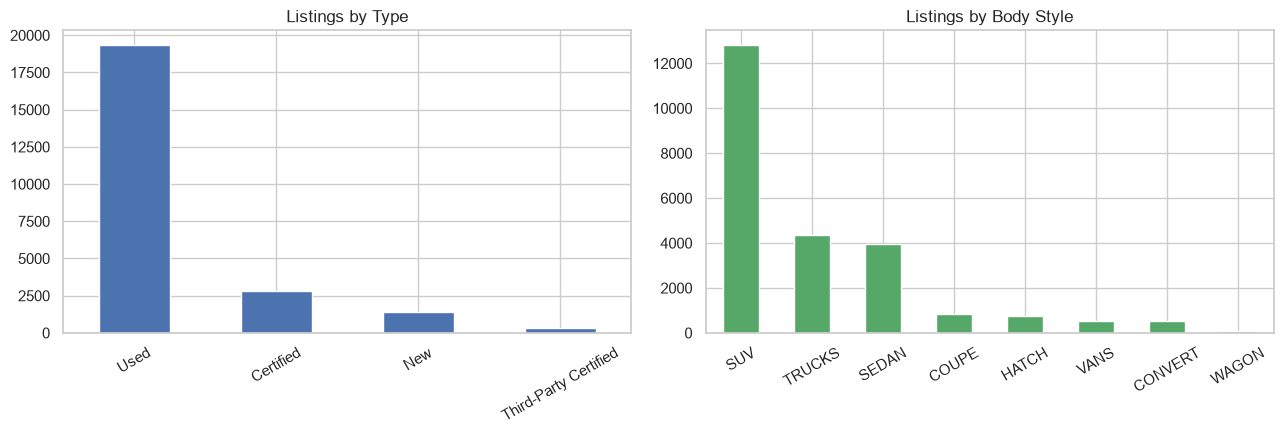

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df["listingType"].value_counts().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Listings by Type")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

df["bodyStyle"].value_counts().plot.bar(ax=axes[1], color="#55A868")
axes[1].set_title("Listings by Body Style")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

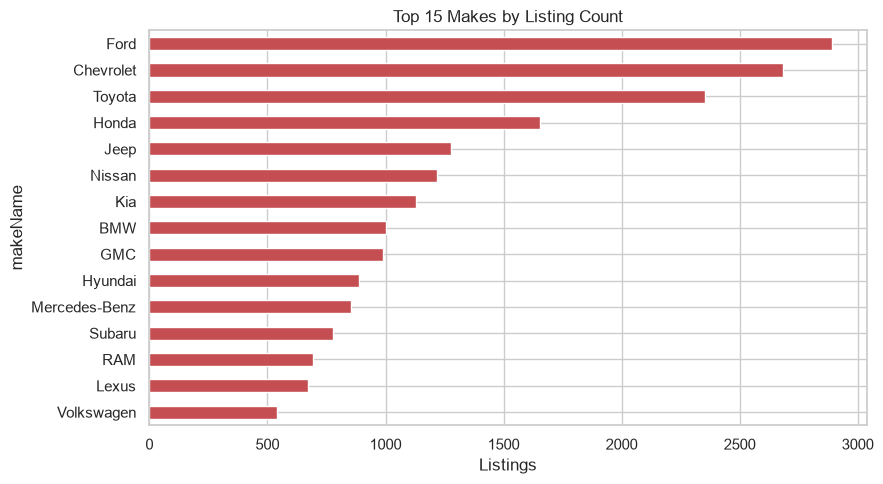


Top 15 models overall:


modelName
F150              715
Equinox           535
Silverado 1500    508
Wrangler          484
1500              427
RAV4              350
CR-V              337
Tacoma            336
HR-V              324
Camry             314
Sierra 1500       309
Civic             308
Rogue             299
Forester          278
Escape            278
Name: count, dtype: int64

In [6]:
top_makes = df["makeName"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
top_makes.sort_values().plot.barh(ax=ax, color="#C44E52")
ax.set_title("Top 15 Makes by Listing Count")
ax.set_xlabel("Listings")
plt.tight_layout()
plt.show()

print("\nTop 15 models overall:")
df["modelName"].value_counts().head(15)

## 4. Geographic distribution

Listing volume by state, plus each state's share of "PREMIUM" priority placements.

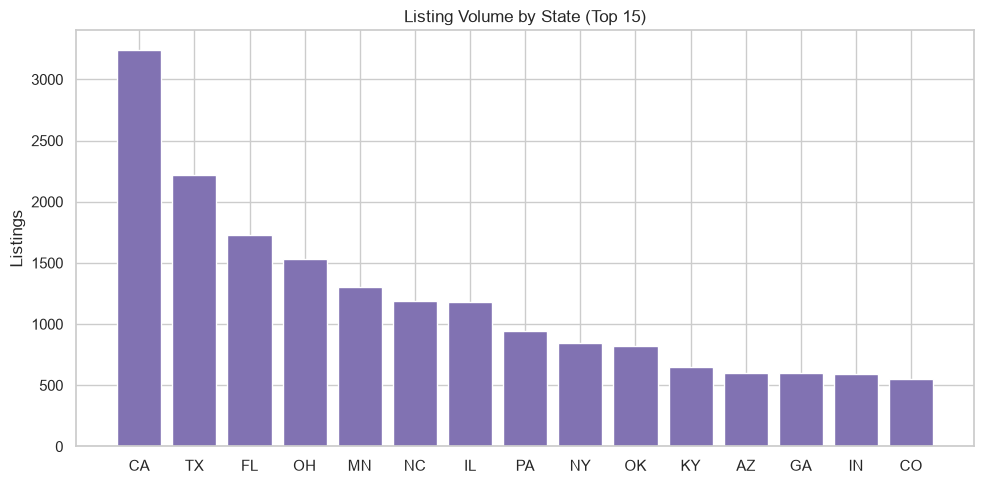

,total,premium,pct_premium
sellerState,,,
CA,3238,0,0.0
TX,2218,0,0.0
FL,1732,0,0.0
OH,1532,0,0.0
MN,1307,0,0.0
NC,1187,0,0.0
IL,1178,0,0.0
PA,942,0,0.0
NY,843,0,0.0


In [7]:
state_stats = (
    df.groupby("sellerState")
    .agg(total=("listingId", "count"), premium=("priority", lambda x: (x == "PREMIUM").sum()))
    .assign(pct_premium=lambda d: (d["premium"] / d["total"] * 100).round(1))
    .sort_values("total", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
top15 = state_stats.head(15)
ax.bar(top15.index, top15["total"], color="#8172B2")
ax.set_title("Listing Volume by State (Top 15)")
ax.set_ylabel("Listings")
plt.tight_layout()
plt.show()

state_stats.head(15)

## 5. KBB pricing analysis

`salePrice` is masked in this sample, so pricing questions use `kbbFairPriceLow`/`kbbFairPriceHigh` (midpoint) and `msrp` (New listings only, ~6% fill rate) instead.

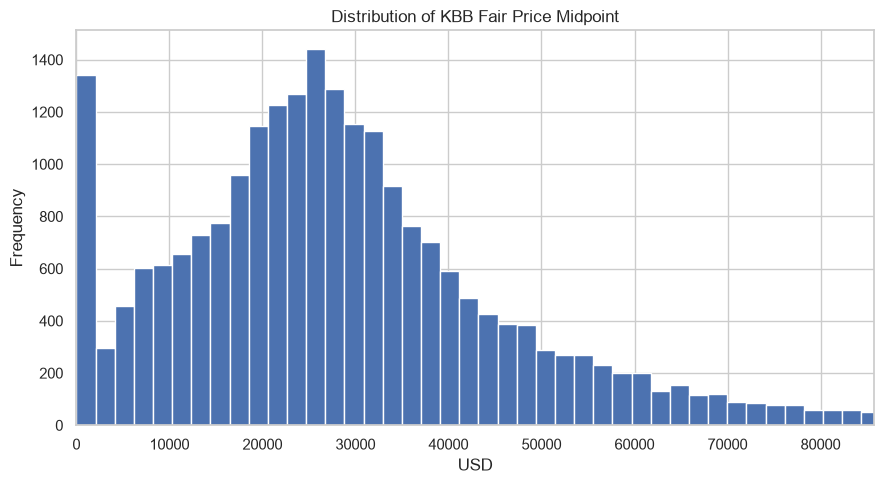

count     22487.0
mean      28665.0
std       18384.0
min           0.0
25%       16822.0
50%       26396.0
75%       37330.0
max      123486.0
Name: kbbMidpoint, dtype: float64

In [8]:
df["kbbMidpoint"] = (df["kbbFairPriceLow"] + df["kbbFairPriceHigh"]) / 2

fig, ax = plt.subplots(figsize=(9, 5))
df["kbbMidpoint"].dropna().plot.hist(bins=60, ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of KBB Fair Price Midpoint")
ax.set_xlabel("USD")
ax.set_xlim(0, df["kbbMidpoint"].quantile(0.99))
plt.tight_layout()
plt.show()

df["kbbMidpoint"].describe().round(0)

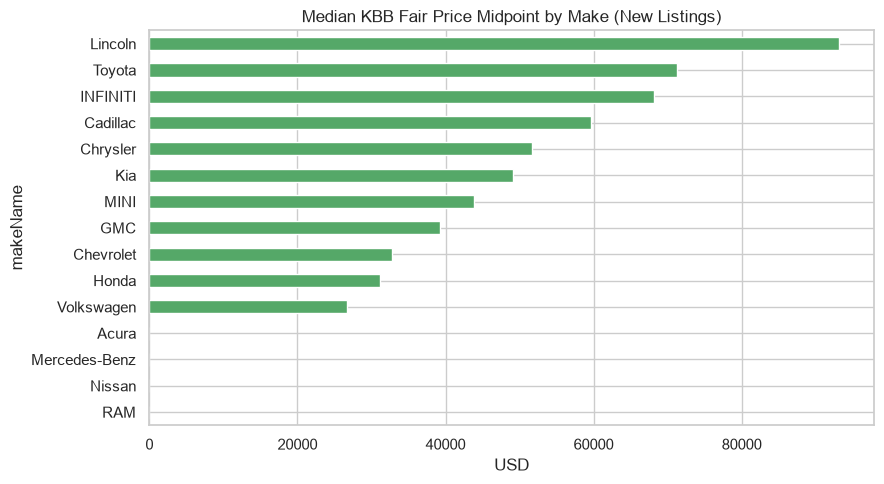

makeName
Lincoln          93200.0
Toyota           71250.0
INFINITI         68100.0
Cadillac         59600.0
Chrysler         51650.0
Kia              49150.0
MINI             43800.0
GMC              39250.0
Chevrolet        32800.0
Honda            31150.0
Volkswagen       26650.0
RAM                  0.0
Nissan               0.0
Mercedes-Benz        0.0
Acura                0.0
Name: kbbMidpoint, dtype: float64

In [9]:
# Median KBB midpoint by make, for New listings (mirrors the dataset README example)
new_cars = df[df["listingType"] == "New"]
median_by_make = (
    new_cars.groupby("makeName")["kbbMidpoint"]
    .median()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 5))
median_by_make.sort_values().plot.barh(ax=ax, color="#55A868")
ax.set_title("Median KBB Fair Price Midpoint by Make (New Listings)")
ax.set_xlabel("USD")
plt.tight_layout()
plt.show()

median_by_make

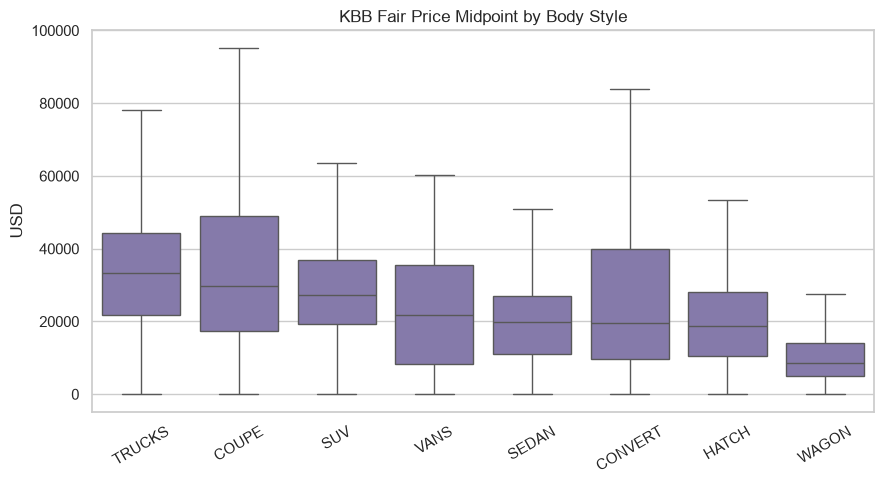

In [10]:
# KBB price range width by body style — a rough proxy for pricing uncertainty/spread
df["kbbRange"] = df["kbbFairPriceHigh"] - df["kbbFairPriceLow"]

fig, ax = plt.subplots(figsize=(9, 5))
order = df.groupby("bodyStyle")["kbbMidpoint"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="bodyStyle", y="kbbMidpoint", order=order, ax=ax, showfliers=False, color="#8172B2")
ax.set_title("KBB Fair Price Midpoint by Body Style")
ax.set_xlabel("")
ax.set_ylabel("USD")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 6. Days-on-market & listing dynamics

How long listings sit, split by fuel type and listing type, plus the "hot"/"newly listed"/"reduced price" activity flags.

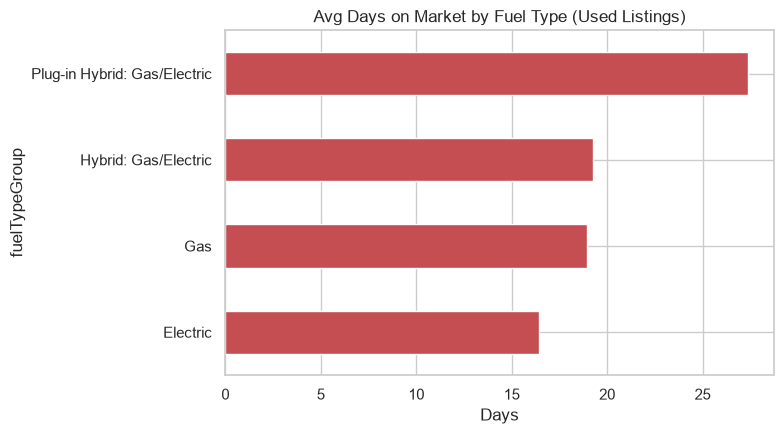

fuelTypeGroup
Electric                        16.5
Gas                             19.0
Hybrid: Gas/Electric            19.3
Plug-in Hybrid: Gas/Electric    27.4
Name: daysOnMarket, dtype: float64

In [11]:
# Average days on market by fuel type group, for used vehicles
used = df[df["listingType"] == "Used"]
dom_by_fuel = used.groupby("fuelTypeGroup")["daysOnMarket"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
dom_by_fuel.plot.barh(ax=ax, color="#C44E52")
ax.set_title("Avg Days on Market by Fuel Type (Used Listings)")
ax.set_xlabel("Days")
plt.tight_layout()
plt.show()

dom_by_fuel.round(1)

In [12]:
# Listing activity flags: share of listings that are hot / newly listed / reduced price,
# broken out by listing type
flag_cols = ["isHot", "isNewlyListed", "isReducedPrice", "hasSpecialOffer"]
flag_rates = df.groupby("listingType")[flag_cols].mean().mul(100).round(1)
flag_rates

,isHot,isNewlyListed,isReducedPrice,hasSpecialOffer
listingType,,,,
Certified,8.7,16.9,25.1,0.0
New,6.8,28.2,0.0,39.5
Third-Party Certified,12.4,11.1,29.7,0.0
Used,3.0,30.8,20.8,0.1


## 7. Fuel type / EV trends

Overall fuel type mix, and which states have the highest share of electric/hybrid listings.

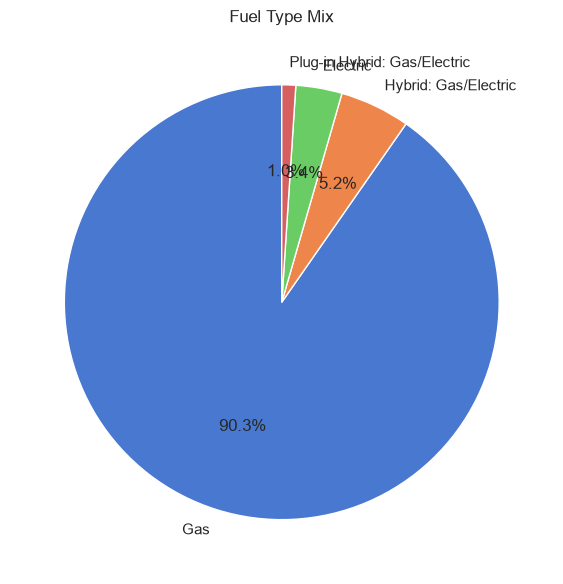

In [13]:
fuel_counts = df["fuelTypeGroup"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(fuel_counts, labels=fuel_counts.index, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("muted", len(fuel_counts)))
ax.set_title("Fuel Type Mix")
plt.tight_layout()
plt.show()

In [14]:
# States with the highest electric+hybrid share, among states with meaningful volume
df["isElectrifed"] = df["fuelTypeGroup"].isin(
    ["Electric", "Hybrid: Gas/Electric", "Plug-in Hybrid: Gas/Electric"]
)
ev_by_state = (
    df.groupby("sellerState")
    .agg(total=("listingId", "count"), electrified=("isElectrifed", "sum"))
    .query("total >= 20")
    .assign(pct_electrified=lambda d: (d["electrified"] / d["total"] * 100).round(1))
    .sort_values("pct_electrified", ascending=False)
    .head(15)
)
ev_by_state

,total,electrified,pct_electrified
sellerState,,,
CA,3238,727,22.5
CO,548,64,11.7
MN,1307,151,11.6
AZ,600,67,11.2
NC,1187,123,10.4
NJ,461,46,10.0
NH,62,6,9.7
IL,1178,111,9.4
OR,291,27,9.3


## 8. Deal quality ratings

KBB's `dealIndicator` rating (Great/Good/Fair/High/Overpriced), and how it relates to KBB price range width.

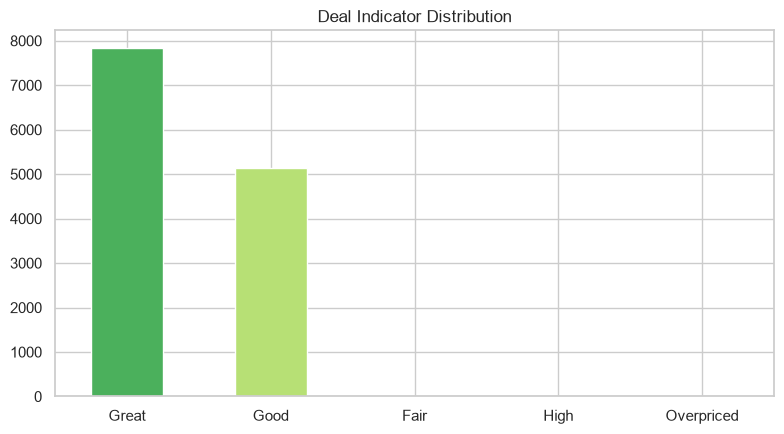

Which makes produce the most 'Great' deals (min 10 listings)?


,total,great,pct_great
makeName,,,
Nissan,1218,549,45.1
Jeep,1277,554,43.4
Buick,242,104,43.0
Genesis,90,38,42.2
Audi,478,201,42.1
Alfa Romeo,22,9,40.9
Lincoln,206,82,39.8
RAM,691,273,39.5
Volvo,174,67,38.5


In [15]:
deal_order = ["Great", "Good", "Fair", "High", "Overpriced"]
deal_counts = df["dealIndicator"].value_counts().reindex(deal_order)

fig, ax = plt.subplots(figsize=(8, 4.5))
deal_counts.plot.bar(ax=ax, color=sns.color_palette("RdYlGn_r", len(deal_order)))
ax.set_title("Deal Indicator Distribution")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("Which makes produce the most 'Great' deals (min 10 listings)?")
great = (
    df.assign(isGreat=df["dealIndicator"] == "Great")
    .groupby("makeName")
    .agg(total=("listingId", "count"), great=("isGreat", "sum"))
    .query("total >= 10")
    .assign(pct_great=lambda d: (d["great"] / d["total"] * 100).round(1))
    .sort_values("pct_great", ascending=False)
    .head(10)
)
great